# Phase 7-A.1 — Automatic External Dataset Acquisition

This notebook downloads and organizes external black-hole reference material for Phase 7-A.

It is intentionally conservative:

- It downloads public EHT GitHub data-product repositories.
- It downloads the public `eht-imaging` repository as a model/example reference source.
- It inventories files.
- It converts image/FITS-like products to normalized PNGs when possible.
- It writes metadata tables that Phase 7-A can use.

Important: public EHT repositories often contain calibrated data, scripts, notebooks, or FITS products rather than ready-made PNG image datasets. If few images are processed automatically, that is normal. The notebook still gives you a documented acquisition pipeline and folder structure.

In [13]:
pip install astropy

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 457.5 kB/s  0:00:21eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 401.5 kB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.7/738.7 kB 517.1 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [astropy]m2/3 [astropy]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
# ================================================================
# 1. Imports and environment check
# ================================================================

import os
import json
import shutil
import zipfile
import hashlib
import urllib.request
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

try:
    import requests
    REQUESTS_AVAILABLE = True
except Exception:
    REQUESTS_AVAILABLE = False

try:
    from astropy.io import fits
    ASTROPY_AVAILABLE = True
except Exception as e:
    ASTROPY_AVAILABLE = False
    print("astropy unavailable. FITS conversion will be skipped.")
    print(e)

try:
    from IPython.display import display
except Exception:
    display = print

print("requests available:", REQUESTS_AVAILABLE)
print("astropy available:", ASTROPY_AVAILABLE)

try:
    import requests
    r = requests.get("https://www.google.com", timeout=10)
    print("Internet check status:", r.status_code)
except Exception as e:
    print("Internet check failed:", e)

requests available: True
astropy available: True
Internet check status: 200


In [15]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PHASE7A1_DIR = OUTPUT_DIR / "phase7A1_external_dataset_acquisition"
PHASE7A1_TABLE_DIR = PHASE7A1_DIR / "tables"
PHASE7A1_FIG_DIR = PHASE7A1_DIR / "figures"
PHASE7A1_REPORT_DIR = PHASE7A1_DIR / "reports"

RAW_EXTERNAL_DIR = DATA_ROOT / "external_raw" / "phase7A1"

REAL_OBS_DIR = DATA_ROOT / "real_observations"
EHT_DIR = REAL_OBS_DIR / "eht"
M87_DIR = EHT_DIR / "m87"
SGRA_DIR = EHT_DIR / "sgrA"
EHT_MISC_DIR = EHT_DIR / "misc"

GRMHD_DIR = DATA_ROOT / "grmhd_simulations"
GRMHD_EHTIM_DIR = GRMHD_DIR / "ehtim_models"

for d in [
    DATA_ROOT, OUTPUT_DIR, PHASE7A1_DIR, PHASE7A1_TABLE_DIR,
    PHASE7A1_FIG_DIR, PHASE7A1_REPORT_DIR, RAW_EXTERNAL_DIR,
    REAL_OBS_DIR, EHT_DIR, M87_DIR, SGRA_DIR, EHT_MISC_DIR,
    GRMHD_DIR, GRMHD_EHTIM_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

DOWNLOAD_EHT_PUBLIC_REPOS = True
DOWNLOAD_EHT_IMAGING_REPO = True
DOWNLOAD_PUBLIC_MEDIA_IMAGES = False

CONVERT_IMAGES_TO_PHASE7_FORMAT = True
CONVERT_FITS_TO_PNG_IF_ASTROPY_AVAILABLE = True

MAX_FILES_PER_SOURCE_TO_PROCESS = 2000
IMAGE_SIZE = 128

OVERWRITE_RAW_DOWNLOADS = False
OVERWRITE_PROCESSED_IMAGES = False

print("Project root:", PROJECT_ROOT)
print("Raw external dir:", RAW_EXTERNAL_DIR)
print("Real EHT dir:", EHT_DIR)
print("GRMHD dir:", GRMHD_DIR)
print("Phase 7-A.1 output:", PHASE7A1_DIR)

Project root: /home/marwa/files/phase1_blackhole_generator
Raw external dir: /home/marwa/files/phase1_blackhole_generator/data/external_raw/phase7A1
Real EHT dir: /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht
GRMHD dir: /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations
Phase 7-A.1 output: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition


In [16]:
# ================================================================
# 3. Source registry
# ================================================================

EHT_GITHUB_SOURCES = [
    {
        "source_id": "eht_2022_D02_01_sgra_calibrated_data",
        "target_hint": "sgrA",
        "url": "https://github.com/eventhorizontelescope/2022-D02-01/archive/refs/heads/main.zip",
        "source_type": "github_zip",
        "description": "First Sgr A* EHT Results: Calibrated Data",
    },
    {
        "source_id": "eht_2022_D02_02_sgra_imaging_pipelines",
        "target_hint": "sgrA",
        "url": "https://github.com/eventhorizontelescope/2022-D02-02/archive/refs/heads/main.zip",
        "source_type": "github_zip",
        "description": "First Sgr A* EHT Results: Imaging Pipelines",
    },
    {
        "source_id": "eht_2022_D02_03_sgra_multiwavelength",
        "target_hint": "sgrA",
        "url": "https://github.com/eventhorizontelescope/2022-D02-03/archive/refs/heads/main.zip",
        "source_type": "github_zip",
        "description": "First Sgr A* EHT Results: Multi-wavelength Data",
    },
    {
        "source_id": "eht_2024_D01_01_m87_calibrated_data",
        "target_hint": "m87",
        "url": "https://github.com/eventhorizontelescope/2024-D01-01/archive/refs/heads/main.zip",
        "source_type": "github_zip",
        "description": "2018 M87 EHT Results: Calibrated Data",
    },
    {
        "source_id": "eht_2024_D02_01_sgra_polarized_data",
        "target_hint": "sgrA",
        "url": "https://github.com/eventhorizontelescope/2024-D02-01/archive/refs/heads/main.zip",
        "source_type": "github_zip",
        "description": "EHT Sagittarius A* Polarized Data",
    },
    {
        "source_id": "eht_2023_D01_01_m87_polarized_data",
        "target_hint": "m87",
        "url": "https://github.com/eventhorizontelescope/2023-D01-01/archive/refs/heads/main.zip",
        "source_type": "github_zip",
        "description": "EHT M87 Polarized Data",
    },
]

EHTIM_SOURCE = {
    "source_id": "achael_eht_imaging_main",
    "target_hint": "grmhd_or_model_reference",
    "url": "https://github.com/achael/eht-imaging/archive/refs/heads/main.zip",
    "source_type": "github_zip",
    "description": "eht-imaging public VLBI imaging/simulation toolkit repository",
}

PUBLIC_MEDIA_SOURCES = [
    {
        "source_id": "media_sgra_nsf_first_image",
        "target_hint": "sgrA",
        "url": "https://nsf-gov-resources.nsf.gov/styles/large/s3/2022-05/EHT_Saggitarius_A_black_hole_image.jpeg",
        "source_type": "media_image",
        "description": "NSF public media image of Sagittarius A* from EHT Collaboration",
        "filename": "sgrA_nsf_public_media.jpeg",
    }
]

source_registry = []
if DOWNLOAD_EHT_PUBLIC_REPOS:
    source_registry.extend(EHT_GITHUB_SOURCES)
if DOWNLOAD_EHT_IMAGING_REPO:
    source_registry.append(EHTIM_SOURCE)
if DOWNLOAD_PUBLIC_MEDIA_IMAGES:
    source_registry.extend(PUBLIC_MEDIA_SOURCES)

source_registry_df = pd.DataFrame(source_registry)
display(source_registry_df)

registry_path = PHASE7A1_TABLE_DIR / "phase7A1_source_registry.csv"
source_registry_df.to_csv(registry_path, index=False)
print("Saved:", registry_path)

,source_id,target_hint,url,source_type,description
0,eht_2022_D02_01_sgra_calibrated_data,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Calibrated Data
1,eht_2022_D02_02_sgra_imaging_pipelines,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Imaging Pipelines
2,eht_2022_D02_03_sgra_multiwavelength,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Multi-wavelength Data
3,eht_2024_D01_01_m87_calibrated_data,m87,https://github.com/eventhorizontelescope/2024-...,github_zip,2018 M87 EHT Results: Calibrated Data
4,eht_2024_D02_01_sgra_polarized_data,sgrA,https://github.com/eventhorizontelescope/2024-...,github_zip,EHT Sagittarius A* Polarized Data
5,eht_2023_D01_01_m87_polarized_data,m87,https://github.com/eventhorizontelescope/2023-...,github_zip,EHT M87 Polarized Data
6,achael_eht_imaging_main,grmhd_or_model_reference,https://github.com/achael/eht-imaging/archive/...,github_zip,eht-imaging public VLBI imaging/simulation too...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/tables/phase7A1_source_registry.csv


In [17]:
# ================================================================
# 4. Download and extraction helpers
# ================================================================

def sha256_file(path):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def safe_filename_from_url(url):
    name = url.split("/")[-1].split("?")[0]
    return name if name else "downloaded_file"

def download_url(url, output_path, overwrite=False, timeout=120):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not overwrite:
        return {
            "success": True, "status": "exists", "output_path": str(output_path),
            "size_bytes": output_path.stat().st_size, "sha256": sha256_file(output_path), "error": "",
        }

    try:
        request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request, timeout=timeout) as response:
            data = response.read()
        with open(output_path, "wb") as f:
            f.write(data)
        return {
            "success": True, "status": "downloaded", "output_path": str(output_path),
            "size_bytes": output_path.stat().st_size, "sha256": sha256_file(output_path), "error": "",
        }
    except Exception as e:
        return {
            "success": False, "status": "failed", "output_path": str(output_path),
            "size_bytes": None, "sha256": None, "error": str(e),
        }

def extract_zip(zip_path, extract_dir, overwrite=False):
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)

    if extract_dir.exists() and any(extract_dir.iterdir()) and not overwrite:
        return {
            "success": True, "status": "exists", "extract_dir": str(extract_dir),
            "n_files": len([p for p in extract_dir.rglob("*") if p.is_file()]), "error": "",
        }

    if extract_dir.exists() and overwrite:
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        return {
            "success": True, "status": "extracted", "extract_dir": str(extract_dir),
            "n_files": len([p for p in extract_dir.rglob("*") if p.is_file()]), "error": "",
        }
    except Exception as e:
        return {"success": False, "status": "failed", "extract_dir": str(extract_dir), "n_files": 0, "error": str(e)}

In [18]:
# ================================================================
# 5. Download sources
# ================================================================

download_rows = []
extract_rows = []

for source in source_registry:
    source_id = source["source_id"]
    url = source["url"]
    source_type = source["source_type"]

    source_raw_dir = RAW_EXTERNAL_DIR / source_id
    source_raw_dir.mkdir(parents=True, exist_ok=True)

    if source_type == "github_zip":
        output_path = source_raw_dir / f"{source_id}.zip"
    else:
        filename = source.get("filename", safe_filename_from_url(url))
        output_path = source_raw_dir / filename

    print("=" * 80)
    print("Downloading source:", source_id)
    print("URL:", url)

    result = download_url(url, output_path, overwrite=OVERWRITE_RAW_DOWNLOADS)

    row = dict(source)
    row.update(result)
    download_rows.append(row)

    print("Status:", result["status"])
    if result["error"]:
        print("Error:", result["error"])

    if result["success"] and source_type == "github_zip":
        extract_dir = source_raw_dir / "extracted"
        ex = extract_zip(output_path, extract_dir, overwrite=OVERWRITE_RAW_DOWNLOADS)
        ex_row = dict(source)
        ex_row.update(ex)
        extract_rows.append(ex_row)
        print("Extract:", ex["status"], "files:", ex["n_files"])

download_df = pd.DataFrame(download_rows)
extract_df = pd.DataFrame(extract_rows)

display(download_df)
display(extract_df)

download_path = PHASE7A1_TABLE_DIR / "phase7A1_download_log.csv"
extract_path = PHASE7A1_TABLE_DIR / "phase7A1_extract_log.csv"

download_df.to_csv(download_path, index=False)
extract_df.to_csv(extract_path, index=False)

print("Saved:", download_path)
print("Saved:", extract_path)

URL: https://github.com/eventhorizontelescope/2022-D02-01/archive/refs/heads/main.zip
Status: exists
Extract: exists files: 76
URL: https://github.com/eventhorizontelescope/2022-D02-02/archive/refs/heads/main.zip
Status: exists
Extract: exists files: 45
URL: https://github.com/eventhorizontelescope/2022-D02-03/archive/refs/heads/main.zip
Status: exists
Extract: exists files: 17
URL: https://github.com/eventhorizontelescope/2024-D01-01/archive/refs/heads/main.zip
Status: exists
Extract: exists files: 81
URL: https://github.com/eventhorizontelescope/2024-D02-01/archive/refs/heads/main.zip
Status: exists
Extract: exists files: 11
URL: https://github.com/eventhorizontelescope/2023-D01-01/archive/refs/heads/main.zip
Status: exists
Extract: exists files: 27
URL: https://github.com/achael/eht-imaging/archive/refs/heads/main.zip
Status: exists
Extract: exists files: 139


,source_id,target_hint,url,source_type,description,success,status,output_path,size_bytes,sha256,error
0,eht_2022_D02_01_sgra_calibrated_data,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Calibrated Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,42946485,870bde390bb289bab9db8c3ab887a3c27c03e92ff8c21c...,
1,eht_2022_D02_02_sgra_imaging_pipelines,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Imaging Pipelines,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,4962162,a196a938a1af83477fba4f150dd4690d3d6ae88fce2f91...,
2,eht_2022_D02_03_sgra_multiwavelength,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Multi-wavelength Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,47205,d220b604f2861c50b5a27afb48bfc00fb9d3746fcb63bd...,
3,eht_2024_D01_01_m87_calibrated_data,m87,https://github.com/eventhorizontelescope/2024-...,github_zip,2018 M87 EHT Results: Calibrated Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,16064513,0a7c9b7b8eee3be05506bcc0f48866987c6aeba6eda2e4...,
4,eht_2024_D02_01_sgra_polarized_data,sgrA,https://github.com/eventhorizontelescope/2024-...,github_zip,EHT Sagittarius A* Polarized Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,4761400,5c38bda8dba0d1e97dbe66933dea349c5bdf39dfd85e05...,
5,eht_2023_D01_01_m87_polarized_data,m87,https://github.com/eventhorizontelescope/2023-...,github_zip,EHT M87 Polarized Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,7718138,4b6cbb1274016e260f1051a6f30406cfa012ea30dbfebb...,
6,achael_eht_imaging_main,grmhd_or_model_reference,https://github.com/achael/eht-imaging/archive/...,github_zip,eht-imaging public VLBI imaging/simulation too...,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,29594119,ce4345aed5e7991f2498392c13a6e2099e2b4d32bdf723...,


,source_id,target_hint,url,source_type,description,success,status,extract_dir,n_files,error
0,eht_2022_D02_01_sgra_calibrated_data,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Calibrated Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,76,
1,eht_2022_D02_02_sgra_imaging_pipelines,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Imaging Pipelines,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,45,
2,eht_2022_D02_03_sgra_multiwavelength,sgrA,https://github.com/eventhorizontelescope/2022-...,github_zip,First Sgr A* EHT Results: Multi-wavelength Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,17,
3,eht_2024_D01_01_m87_calibrated_data,m87,https://github.com/eventhorizontelescope/2024-...,github_zip,2018 M87 EHT Results: Calibrated Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,81,
4,eht_2024_D02_01_sgra_polarized_data,sgrA,https://github.com/eventhorizontelescope/2024-...,github_zip,EHT Sagittarius A* Polarized Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,11,
5,eht_2023_D01_01_m87_polarized_data,m87,https://github.com/eventhorizontelescope/2023-...,github_zip,EHT M87 Polarized Data,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,27,
6,achael_eht_imaging_main,grmhd_or_model_reference,https://github.com/achael/eht-imaging/archive/...,github_zip,eht-imaging public VLBI imaging/simulation too...,True,exists,/home/marwa/files/phase1_blackhole_generator/d...,139,


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/tables/phase7A1_download_log.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/tables/phase7A1_extract_log.csv


In [19]:
# ================================================================
# 6. Inventory raw external files
# ================================================================

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
FITS_EXTS = {".fits", ".fit", ".fts"}

inventory_rows = []

for source in source_registry:
    source_id = source["source_id"]
    source_dir = RAW_EXTERNAL_DIR / source_id
    files = [p for p in source_dir.rglob("*") if p.is_file()]

    for p in files:
        suffix = p.suffix.lower()
        if suffix in IMAGE_EXTS:
            file_type = "image"
        elif suffix in FITS_EXTS:
            file_type = "fits"
        elif suffix == ".zip":
            file_type = "zip"
        elif suffix in {".csv", ".txt", ".dat", ".npy", ".npz", ".h5", ".hdf5"}:
            file_type = suffix.replace(".", "")
        else:
            file_type = "other"

        inventory_rows.append({
            "source_id": source_id,
            "source_type": source["source_type"],
            "target_hint": source["target_hint"],
            "description": source["description"],
            "path": str(p),
            "filename": p.name,
            "suffix": suffix,
            "file_type": file_type,
            "size_bytes": p.stat().st_size,
            "sha256": sha256_file(p),
        })

raw_inventory_df = pd.DataFrame(inventory_rows)

if len(raw_inventory_df):
    display(raw_inventory_df["file_type"].value_counts().rename("count").reset_index())
    display(raw_inventory_df.head())
else:
    print("No raw files inventoried.")

inventory_path = PHASE7A1_TABLE_DIR / "phase7A1_raw_file_inventory.csv"
raw_inventory_df.to_csv(inventory_path, index=False)
print("Saved:", inventory_path)

,file_type,count
0,other,244
1,txt,83
2,csv,64
3,zip,7
4,fits,3
5,hdf5,2


,source_id,source_type,target_hint,description,path,filename,suffix,file_type,size_bytes,sha256
0,eht_2022_D02_01_sgra_calibrated_data,github_zip,sgrA,First Sgr A* EHT Results: Calibrated Data,/home/marwa/files/phase1_blackhole_generator/d...,eht_2022_D02_01_sgra_calibrated_data.zip,.zip,zip,42946485,870bde390bb289bab9db8c3ab887a3c27c03e92ff8c21c...
1,eht_2022_D02_01_sgra_calibrated_data,github_zip,sgrA,First Sgr A* EHT Results: Calibrated Data,/home/marwa/files/phase1_blackhole_generator/d...,run.sh,.sh,other,985,1fd94cc12e558ca9e443acd20ae37af212f41064e2131e...
2,eht_2022_D02_01_sgra_calibrated_data,github_zip,sgrA,First Sgr A* EHT Results: Calibrated Data,/home/marwa/files/phase1_blackhole_generator/d...,EHTC_FirstSgrAResults_May2022_txt.tgz,.tgz,other,7465338,9e7e40354fb587b74475359982cacbb5c9b14403770827...
3,eht_2022_D02_01_sgra_calibrated_data,github_zip,sgrA,First Sgr A* EHT Results: Calibrated Data,/home/marwa/files/phase1_blackhole_generator/d...,INVENTORY.txt,.txt,txt,4420,3c2f58165e917ad576814b136550bab09eb7aecf7cc2f7...
4,eht_2022_D02_01_sgra_calibrated_data,github_zip,sgrA,First Sgr A* EHT Results: Calibrated Data,/home/marwa/files/phase1_blackhole_generator/d...,EHTC_FirstSgrAResults_May2022_csv.tgz,.tgz,other,7083259,709f322cd825669e1b30dacb3c9093f016ae3c931a1936...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/tables/phase7A1_raw_file_inventory.csv


In [20]:
# ================================================================
# 7. Image and FITS conversion helpers
# ================================================================

def normalize_image_array(arr, percentiles=(1, 99)):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim > 2:
        arr = arr[..., 0]

    finite = np.isfinite(arr)
    if not finite.any():
        return np.zeros_like(arr, dtype=np.float32)

    arr = np.where(finite, arr, np.nanmedian(arr[finite]))

    lo, hi = np.percentile(arr, percentiles)
    if hi <= lo:
        mn, mx = np.min(arr), np.max(arr)
        if mx > mn:
            out = (arr - mn) / (mx - mn)
        else:
            out = np.zeros_like(arr, dtype=np.float32)
    else:
        out = (arr - lo) / (hi - lo)

    return np.clip(out, 0, 1).astype(np.float32)

def save_array_as_png(arr, output_path, size=128):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    arr = normalize_image_array(arr)
    img = Image.fromarray((arr * 255).astype(np.uint8)).convert("L")
    img = ImageOps.fit(img, (size, size), method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))
    img.save(output_path)
    return output_path

def convert_regular_image(input_path, output_path, size=128):
    input_path = Path(input_path)
    output_path = Path(output_path)

    img = Image.open(input_path).convert("L")
    img = ImageOps.fit(img, (min(img.size), min(img.size)), method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))
    img = img.resize((size, size), Image.Resampling.LANCZOS)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(output_path)
    return output_path

def read_fits_image(input_path):
    if not ASTROPY_AVAILABLE:
        return None

    try:
        hdul = fits.open(input_path)
        data = None

        for hdu in hdul:
            if hdu.data is None:
                continue
            arr = np.asarray(hdu.data)
            if arr.size == 0:
                continue

            arr = np.squeeze(arr)
            if arr.ndim == 2:
                data = arr
                break
            elif arr.ndim > 2:
                while arr.ndim > 2:
                    arr = arr[0]
                data = arr
                break

        hdul.close()
        return data

    except Exception:
        return None

In [21]:
# ================================================================
# 8. Process downloaded data into Phase 7-A folders
# ================================================================

processed_rows = []

if len(raw_inventory_df) == 0:
    print("No raw files to process.")
else:
    process_df = raw_inventory_df[raw_inventory_df["file_type"].isin(["image", "fits"])].copy()
    print("Candidate image/FITS files:", len(process_df))

    for source_id, sub in process_df.groupby("source_id"):
        sub = sub.head(MAX_FILES_PER_SOURCE_TO_PROCESS)

        for _, row in sub.iterrows():
            input_path = Path(row["path"])
            target_hint = row["target_hint"]
            file_type = row["file_type"]

            if "sgr" in str(target_hint).lower():
                output_base = SGRA_DIR
                domain_label = "eht_sgrA"
            elif "m87" in str(target_hint).lower():
                output_base = M87_DIR
                domain_label = "eht_m87"
            elif source_id == "achael_eht_imaging_main" or "grmhd" in str(target_hint).lower() or "model" in str(target_hint).lower():
                output_base = GRMHD_EHTIM_DIR
                domain_label = "grmhd_or_model_reference"
            else:
                output_base = EHT_MISC_DIR
                domain_label = "eht_misc"

            output_filename = f"{source_id}__{input_path.stem}.png"
            output_path = output_base / output_filename

            if output_path.exists() and not OVERWRITE_PROCESSED_IMAGES:
                status = "exists"
                success = True
                error = ""
            else:
                try:
                    if file_type == "image":
                        convert_regular_image(input_path, output_path, size=IMAGE_SIZE)
                        status = "converted_image"
                        success = True
                        error = ""
                    elif file_type == "fits" and CONVERT_FITS_TO_PNG_IF_ASTROPY_AVAILABLE and ASTROPY_AVAILABLE:
                        arr = read_fits_image(input_path)
                        if arr is None:
                            raise RuntimeError("Could not read FITS image array.")
                        save_array_as_png(arr, output_path, size=IMAGE_SIZE)
                        status = "converted_fits"
                        success = True
                        error = ""
                    else:
                        status = "skipped"
                        success = False
                        error = "Unsupported conversion or astropy unavailable."
                except Exception as e:
                    status = "failed"
                    success = False
                    error = str(e)

            processed_rows.append({
                "source_id": source_id,
                "domain_label": domain_label,
                "target_hint": target_hint,
                "input_path": str(input_path),
                "output_path": str(output_path),
                "file_type": file_type,
                "status": status,
                "success": success,
                "error": error,
                "output_exists": output_path.exists(),
                "output_sha256": sha256_file(output_path),
            })

processed_df = pd.DataFrame(processed_rows)

if len(processed_df):
    display(processed_df["status"].value_counts().rename("count").reset_index())
    display(processed_df.head())
else:
    print("No files processed.")

processed_path = PHASE7A1_TABLE_DIR / "phase7A1_processed_image_log.csv"
processed_df.to_csv(processed_path, index=False)
print("Saved:", processed_path)

Candidate image/FITS files: 3


,status,count
0,converted_fits,3


,source_id,domain_label,target_hint,input_path,output_path,file_type,status,success,error,output_exists,output_sha256
0,eht_2022_D02_02_sgra_imaging_pipelines,eht_sgrA,sgrA,/home/marwa/files/phase1_blackhole_generator/d...,/home/marwa/files/phase1_blackhole_generator/d...,fits,converted_fits,True,,True,10b7d9a1c4da38d2a964d1586404923435c20a15f7f90d...
1,eht_2022_D02_02_sgra_imaging_pipelines,eht_sgrA,sgrA,/home/marwa/files/phase1_blackhole_generator/d...,/home/marwa/files/phase1_blackhole_generator/d...,fits,converted_fits,True,,True,f0b3630214c74fa9bf9e9c3be57a621b02cb67ae7b3dc7...
2,eht_2022_D02_02_sgra_imaging_pipelines,eht_sgrA,sgrA,/home/marwa/files/phase1_blackhole_generator/d...,/home/marwa/files/phase1_blackhole_generator/d...,fits,converted_fits,True,,True,cd0051e6764e2e04129b6c7544fb88d7185cb9e4c63583...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/tables/phase7A1_processed_image_log.csv


In [22]:
# ================================================================
# 9. Build metadata table for Phase 7-A
# ================================================================

def list_images_recursive(folder):
    rows = []
    folder = Path(folder)
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp"]:
        rows.extend(folder.rglob(ext))
    return sorted(set(rows))

metadata_rows = []
folders = [
    ("eht_m87", M87_DIR),
    ("eht_sgrA", SGRA_DIR),
    ("eht_misc", EHT_MISC_DIR),
    ("grmhd_ehtim_models", GRMHD_EHTIM_DIR),
    ("grmhd_root", GRMHD_DIR),
]

seen = set()

for domain_label, folder in folders:
    for p in list_images_recursive(folder):
        if p in seen:
            continue
        seen.add(p)

        metadata_rows.append({
            "domain_label": domain_label,
            "sample_id": p.stem,
            "image_path": str(p),
            "filename": p.name,
            "folder": str(folder),
            "sha256": sha256_file(p),
            "size_bytes": p.stat().st_size,
        })

phase7_external_metadata_df = pd.DataFrame(metadata_rows)

display(phase7_external_metadata_df.head())
print("External processed images:", len(phase7_external_metadata_df))

metadata_path = PHASE7A1_TABLE_DIR / "phase7A1_external_image_metadata.csv"
phase7_external_metadata_df.to_csv(metadata_path, index=False)
print("Saved:", metadata_path)

data_metadata_path = DATA_ROOT / "phase7A_external_image_metadata.csv"
phase7_external_metadata_df.to_csv(data_metadata_path, index=False)
print("Saved:", data_metadata_path)

,domain_label,sample_id,image_path,filename,folder,sha256,size_bytes
0,eht_sgrA,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,/home/marwa/files/phase1_blackhole_generator/d...,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,/home/marwa/files/phase1_blackhole_generator/d...,10b7d9a1c4da38d2a964d1586404923435c20a15f7f90d...,2917
1,eht_sgrA,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,cd0051e6764e2e04129b6c7544fb88d7185cb9e4c63583...,3447
2,eht_sgrA,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,f0b3630214c74fa9bf9e9c3be57a621b02cb67ae7b3dc7...,3594


External processed images: 3
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/tables/phase7A1_external_image_metadata.csv
Saved: /home/marwa/files/phase1_blackhole_generator/data/phase7A_external_image_metadata.csv


No images for: EHT M87


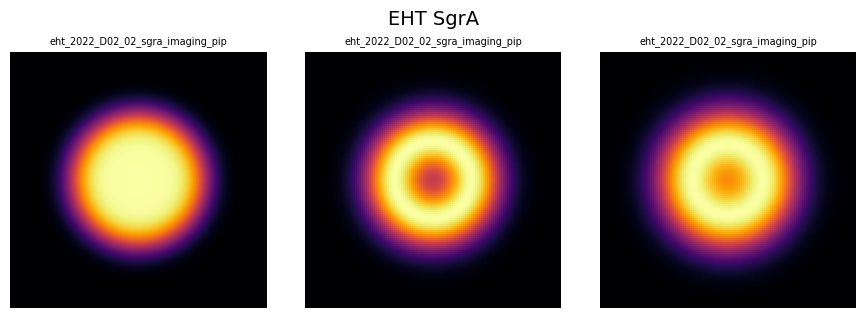

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/figures/preview_eht_sgra.png
No images for: GRMHD / eht-imaging Models
No images for: EHT Misc


In [23]:
# ================================================================
# 10. Visual preview of acquired images
# ================================================================

def show_folder_preview(folder, title, n=12):
    files = list_images_recursive(folder)[:n]

    if len(files) == 0:
        print("No images for:", title)
        return

    cols = min(4, len(files))
    rows = int(np.ceil(len(files) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.2 * rows), squeeze=False)
    axes = axes.reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, p in zip(axes, files):
        img = Image.open(p).convert("L")
        ax.imshow(img, cmap="inferno", vmin=0, vmax=255)
        ax.set_title(p.name[:32], fontsize=7)
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    out_path = PHASE7A1_FIG_DIR / f"preview_{title.lower().replace(' ', '_').replace('*', '')}.png"
    plt.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

show_folder_preview(M87_DIR, "EHT M87", n=12)
show_folder_preview(SGRA_DIR, "EHT SgrA", n=12)
show_folder_preview(GRMHD_EHTIM_DIR, "GRMHD / eht-imaging Models", n=12)
show_folder_preview(EHT_MISC_DIR, "EHT Misc", n=12)

In [24]:
# ================================================================
# 11. Acquisition report
# ================================================================

summary = {
    "created_at": datetime.now().isoformat(),
    "project_root": str(PROJECT_ROOT),
    "raw_external_dir": str(RAW_EXTERNAL_DIR),
    "real_observations_dir": str(REAL_OBS_DIR),
    "grmhd_dir": str(GRMHD_DIR),
    "m87_dir": str(M87_DIR),
    "sgra_dir": str(SGRA_DIR),
    "grmhd_ehtim_dir": str(GRMHD_EHTIM_DIR),
    "n_sources_registered": len(source_registry),
    "n_downloaded_success": int(download_df["success"].sum()) if len(download_df) and "success" in download_df.columns else 0,
    "n_raw_files": int(len(raw_inventory_df)),
    "n_processed_images": int(len(phase7_external_metadata_df)),
    "n_m87_images": int(len(list_images_recursive(M87_DIR))),
    "n_sgra_images": int(len(list_images_recursive(SGRA_DIR))),
    "n_grmhd_images": int(len(list_images_recursive(GRMHD_EHTIM_DIR))),
    "astropy_available": ASTROPY_AVAILABLE,
    "requests_available": REQUESTS_AVAILABLE,
    "source_registry_csv": str(registry_path),
    "download_log_csv": str(download_path),
    "extract_log_csv": str(extract_path),
    "raw_inventory_csv": str(inventory_path),
    "processed_log_csv": str(processed_path),
    "metadata_csv": str(metadata_path),
}

summary_path = PHASE7A1_DIR / "phase7A1_acquisition_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

report_text = f'''# Phase 7-A.1 External Dataset Acquisition Report

Created: {summary["created_at"]}

## Output folders

- Raw external data: {RAW_EXTERNAL_DIR}
- Real observations: {REAL_OBS_DIR}
- EHT M87: {M87_DIR}
- EHT Sgr A*: {SGRA_DIR}
- GRMHD / model references: {GRMHD_EHTIM_DIR}

## Counts

- Registered sources: {summary["n_sources_registered"]}
- Successful downloads: {summary["n_downloaded_success"]}
- Raw files inventoried: {summary["n_raw_files"]}
- Processed images: {summary["n_processed_images"]}
- M87 images: {summary["n_m87_images"]}
- Sgr A* images: {summary["n_sgra_images"]}
- GRMHD / eht-imaging model images: {summary["n_grmhd_images"]}

## Notes

This acquisition notebook is designed as a reproducible bridge into Phase 7-A.

The resulting folders can be used directly by the Phase 7-A Real Observation Consistency Study notebook.

Important limitation: public EHT repositories often contain calibrated interferometric data, scripts, notebooks, or FITS products rather than ready-made PNG image datasets. If very few images are processed automatically, this is normal. Add manually downloaded EHT reconstructed images or GRMHD image libraries into the folders created above.

## Recommended next step

Rerun Phase 7-A after this acquisition step.

If the processed image count is still low, manually add GRMHD-rendered PNG/FITS images to:

{GRMHD_DIR}

and EHT reconstruction/media images to:

{EHT_DIR}
'''

report_md_path = PHASE7A1_REPORT_DIR / "phase7A1_acquisition_report.md"
report_txt_path = PHASE7A1_REPORT_DIR / "phase7A1_acquisition_report.txt"

with open(report_md_path, "w") as f:
    f.write(report_text)

with open(report_txt_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved:", summary_path)
print("Saved:", report_md_path)
print("Saved:", report_txt_path)

# Phase 7-A.1 External Dataset Acquisition Report

Created: 2026-06-13T21:20:50.254524

## Output folders

- Raw external data: /home/marwa/files/phase1_blackhole_generator/data/external_raw/phase7A1
- Real observations: /home/marwa/files/phase1_blackhole_generator/data/real_observations
- EHT M87: /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/m87
- EHT Sgr A*: /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/sgrA
- GRMHD / model references: /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/ehtim_models

## Counts

- Registered sources: 7
- Successful downloads: 7
- Raw files inventoried: 403
- Processed images: 3
- M87 images: 0
- Sgr A* images: 3
- GRMHD / eht-imaging model images: 0

## Notes

This acquisition notebook is designed as a reproducible bridge into Phase 7-A.

The resulting folders can be used directly by the Phase 7-A Real Observation Consistency Study notebook.

Important limitation: public EHT reposito

In [25]:
# ================================================================
# 12. Final index
# ================================================================

index = {
    "created_at": datetime.now().isoformat(),
    "phase": "Phase 7-A.1",
    "name": "Automatic External Dataset Acquisition",
    "project_root": str(PROJECT_ROOT),
    "outputs": {
        "phase7A1_dir": str(PHASE7A1_DIR),
        "tables": str(PHASE7A1_TABLE_DIR),
        "figures": str(PHASE7A1_FIG_DIR),
        "reports": str(PHASE7A1_REPORT_DIR),
        "raw_external": str(RAW_EXTERNAL_DIR),
        "real_observations": str(REAL_OBS_DIR),
        "grmhd": str(GRMHD_DIR),
    },
    "summary_json": str(summary_path),
    "metadata_csv": str(metadata_path),
    "main_tables": {
        "source_registry": str(registry_path),
        "download_log": str(download_path),
        "extract_log": str(extract_path),
        "raw_inventory": str(inventory_path),
        "processed_log": str(processed_path),
        "external_metadata": str(metadata_path),
    },
}

index_path = PHASE7A1_DIR / "phase7A1_index.json"

with open(index_path, "w") as f:
    json.dump(index, f, indent=2)

print("=" * 80)
print("Phase 7-A.1 complete")
print("=" * 80)
print("Index:", index_path)
print("Processed external image metadata:", metadata_path)
print("Now rerun Phase 7-A.")
print("=" * 80)

Phase 7-A.1 complete
Index: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/phase7A1_index.json
Processed external image metadata: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A1_external_dataset_acquisition/tables/phase7A1_external_image_metadata.csv
Now rerun Phase 7-A.
